<a href="https://colab.research.google.com/github/Sakshamg0126/ArtExtract--GSoc26/blob/main/Image_Similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install kaggle
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d lgmoneda/rijksmuseum --unzip -p /content/rijksmuseum_data


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/lgmoneda/rijksmuseum
License(s): ODbL-1.0
100% 4.99G/4.99G [05:21<00:00, 16.7MB/s]



In [45]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0
from torchvision import transforms
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

DEVICE="cuda" if torch.cuda.is_available() else"cpu"
print("Using device:",DEVICE)

Using device: cuda


In [10]:
data_path = Path("/content/rijksmuseum_data")

In [11]:
all_images=list(data_path.rglob("*/*.jpg"))+\
list(data_path.rglob("*/*.png"))+\
list(data_path.rglob("*/*.jpeg"))

In [12]:
print("total iMages:",len(all_images))
print("Sample",all_images[:5])

total iMages: 24554
Sample [PosixPath('/content/rijksmuseum_data/rijksmuseum/photomechanical print/RP-F-2001-7-755-3.jpg'), PosixPath('/content/rijksmuseum_data/rijksmuseum/photomechanical print/RP-F-2001-7-1639C-52.jpg'), PosixPath('/content/rijksmuseum_data/rijksmuseum/photomechanical print/RP-F-2001-7-824-1.jpg'), PosixPath('/content/rijksmuseum_data/rijksmuseum/photomechanical print/RP-F-2001-7-67-47.jpg'), PosixPath('/content/rijksmuseum_data/rijksmuseum/photomechanical print/RP-F-2001-7-1590-26.jpg')]


In [15]:
transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [34]:
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()

        base_model = efficientnet_b0(weights="DEFAULT")

        self.features = base_model.features
        self.pool = nn.AdaptiveAvgPool2d(1)
    def forward(self,x):
     x=self.features(x)
     x=self.pool(x)
     x=x.view(x.size(0),-1)
     return x

In [43]:
from torchvision.models import efficientnet_b0
import torch.nn as nn

class FeatureExtractor(nn.Module):
    def __init__(self):
        super(FeatureExtractor, self).__init__()

        base_model = efficientnet_b0(weights="DEFAULT")

        self.features = base_model.features
        self.pool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):   # ✅ IMPORTANT: self included
        x = self.features(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return x

In [44]:
model=FeatureExtractor().to(DEVICE)
model.eval()

FeatureExtractor(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormAct

In [35]:
features=[]
image_paths=[]

In [54]:
features = []
image_paths = []

count = 0
failed = 0

print("Extracting features...")

with torch.no_grad():
    for i, img_path in enumerate(all_images):

        try:
            img = Image.open(img_path).convert("RGB")
            img = transform(img).unsqueeze(0).to(DEVICE)

            feat = model(img)   # keep on GPU first

            feat = feat.cpu().numpy()

            features.append(feat.squeeze())
            image_paths.append(str(img_path))

            count += 1

            if count % 500 == 0:
                print(f"✅ Processed: {count}")

        except Exception as e:
            failed += 1
            print(f"❌ Error at {img_path}: {e}")
            continue

print("\nDONE")
print("Successful:", count)
print("Failed:", failed)

Extracting features...
✅ Processed: 500
✅ Processed: 1000
✅ Processed: 1500
✅ Processed: 2000
✅ Processed: 2500
✅ Processed: 3000
✅ Processed: 3500
✅ Processed: 4000
✅ Processed: 4500
✅ Processed: 5000
✅ Processed: 5500
✅ Processed: 6000
✅ Processed: 6500
✅ Processed: 7000
✅ Processed: 7500
✅ Processed: 8000
✅ Processed: 8500
✅ Processed: 9000
✅ Processed: 9500
✅ Processed: 10000
✅ Processed: 10500
✅ Processed: 11000
❌ Error at /content/rijksmuseum_data/rijksmuseum/drawing/RP-T-1940-571.jpg: cannot identify image file '/content/rijksmuseum_data/rijksmuseum/drawing/RP-T-1940-571.jpg'
✅ Processed: 11500
✅ Processed: 12000
✅ Processed: 12500
✅ Processed: 13000
✅ Processed: 13500
✅ Processed: 14000
✅ Processed: 14500
✅ Processed: 15000
✅ Processed: 15500
✅ Processed: 16000
✅ Processed: 16500
✅ Processed: 17000
✅ Processed: 17500
✅ Processed: 18000
✅ Processed: 18500
✅ Processed: 19000
✅ Processed: 19500
✅ Processed: 20000
✅ Processed: 20500
✅ Processed: 21000
✅ Processed: 21500
✅ Processed

In [56]:
features = np.array(features)

# normalize
features = features / np.linalg.norm(features, axis=1, keepdims=True)

print(features.shape)

(24553, 1280)


In [57]:
from sklearn.metrics.pairwise import cosine_similarity

def find_similar(query_image, top_k=5):

    # preprocess
    img = transform(query_image).unsqueeze(0).to(DEVICE)

    # extract feature
    with torch.no_grad():
        query_feat = model(img).cpu().numpy()

    # normalize
    query_feat = query_feat / np.linalg.norm(query_feat)

    # similarity
    similarities = cosine_similarity(query_feat, features)[0]

    # top matches
    indices = similarities.argsort()[-top_k:][::-1]

    return indices

In [58]:
import matplotlib.pyplot as plt
from PIL import Image

def show_results(query_image, indices):

    plt.figure(figsize=(12, 4))

    # Query image
    plt.subplot(1, len(indices)+1, 1)
    plt.imshow(query_image)
    plt.title("Query")
    plt.axis("off")

    # Similar images
    for i, idx in enumerate(indices):
        img = Image.open(image_paths[idx])

        plt.subplot(1, len(indices)+1, i+2)
        plt.imshow(img)
        plt.axis("off")

    plt.show()

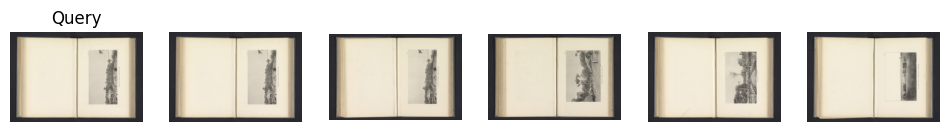

In [59]:
# pick any image
query_img = Image.open(image_paths[100]).convert("RGB")

indices = find_similar(query_img, top_k=5)

show_results(query_img, indices)